In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_tokens_usage_graph=pd.read_json("logs/tokens_usage_graph.json")
print(df_tokens_usage_graph.shape)
df_tokens_usage_graph["total_price"]=df_tokens_usage_graph["completion_price"]+df_tokens_usage_graph["input_price"]
display(df_tokens_usage_graph)


(187, 11)


,hash_query,rag_type,query,date,input_tokens,completion_tokens,reasoning_tokens,input_price,completion_price,reasoning_price,model,total_price
0,4c876d3f4b72bf45d3c57b0bd06f7050,pathrag,\n Peux tu me faire une synthèse de...,2026-03-07 15:00:40.316437,515,73,0,0.00014,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita,0.00017
1,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:25:39.868283,462,64,0,0.00012,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita,0.00015
2,d98228ef4922f022fd3993e5ef8e10a3,pathrag,"Pour chaque intervenant, peux-tu résumer son ...",2026-03-07 15:26:25.950428,22881,1259,0,0.00618,0.00050,0,deepseek-ai/DeepSeek-V3.2:novita,0.00668
3,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:27:14.411920,492,70,0,0.00013,0.00003,0,deepseek-ai/DeepSeek-V3.2:novita,0.00016
4,efa6970869eebd54536e6367c0132332,pathrag,"\n Dans ce qui est dit, qu’...",2026-03-07 15:28:08.884586,22678,1626,0,0.00612,0.00065,0,deepseek-ai/DeepSeek-V3.2:novita,0.00677
...,...,...,...,...,...,...,...,...,...,...,...,...
182,1ee9f6a9598940f7eacd129a981365cf,pathrag,Quelles sont les mesures environnementales con...,2026-03-17 17:58:59.293744,21952,683,0,0.00088,0.00017,0,openai/gpt-oss-120b:cheapest,0.00105
183,dc65a6f79367b483898172bf5cf4fd8e,pathrag,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17 17:59:23.029577,492,489,0,0.00002,0.00012,0,openai/gpt-oss-120b:cheapest,0.00014
184,dc65a6f79367b483898172bf5cf4fd8e,pathrag,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17 17:59:37.396216,20899,413,0,0.00084,0.00010,0,openai/gpt-oss-120b:cheapest,0.00094
185,26c184375ed9f40088ed1113b5e201a4,pathrag,Quel a été l'impact exact de la suspension de ...,2026-03-17 18:00:11.935576,478,435,0,0.00002,0.00011,0,openai/gpt-oss-120b:cheapest,0.00013


### Ananlyse activité graphs
1. Tokens

model
deepseek-ai/DeepSeek-V3.2:novita    34
Name: count, dtype: int64

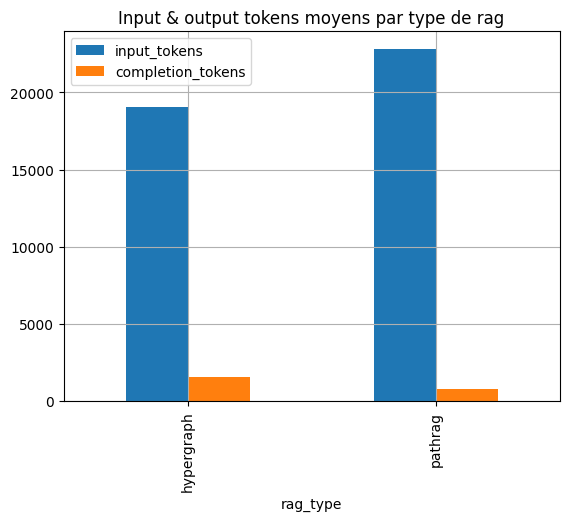

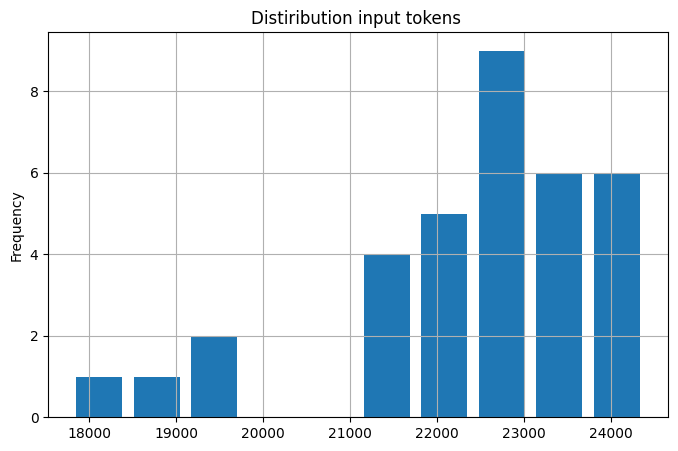

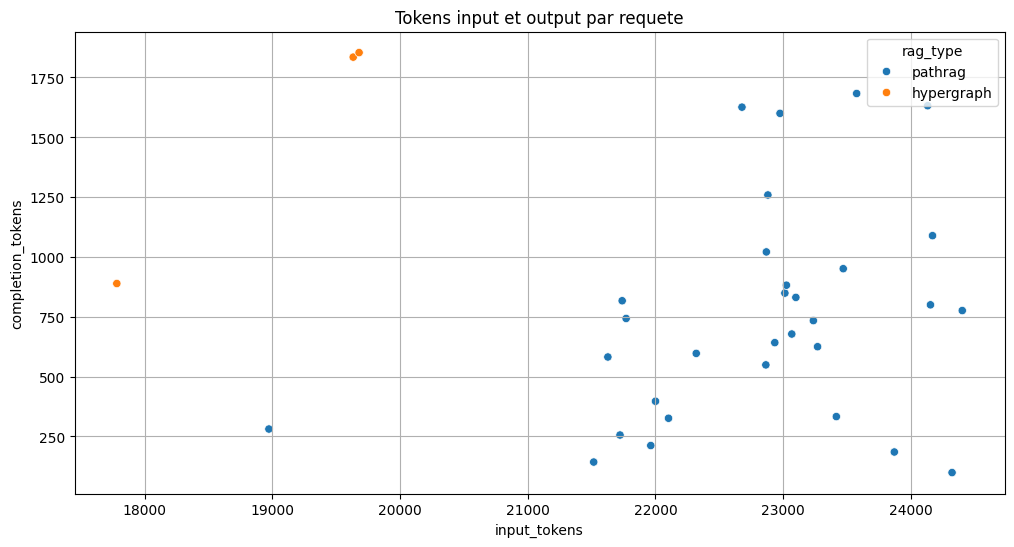

In [142]:
display(df_tokens_usage_graph["model"].value_counts())

df_tokens_usage_graph=df_tokens_usage_graph[
    (df_tokens_usage_graph['model']=="deepseek-ai/DeepSeek-V3.2:novita") 
    # exclure les appels entity extraction hypergraph
    #& (df_tokens_usage_graph["input_tokens"]>6000)
]


df_tokens_usage_graph_tokens_grouped=df_tokens_usage_graph.groupby(["hash_query", 'rag_type', ])[["input_tokens", "completion_tokens"]].sum().reset_index(drop=False)



# plt.bar(data=df_tokens_usage_graph_tokens_grouped)
df_tokens_usage_graph_tokens_grouped.groupby("rag_type")[["input_tokens", "completion_tokens"]].mean().plot(kind='bar', title="Input & output tokens moyens par type de rag")
plt.grid(True)
plt.show()

df_tokens_usage_graph["input_tokens"].plot(kind='hist', title="Distiribution input tokens ", figsize=(8, 5), grid=True, rwidth=0.8, )
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_tokens_usage_graph_tokens_grouped, x="input_tokens", y="completion_tokens", hue="rag_type")
plt.grid(True)
plt.title(label="Tokens input et output par requete")
plt.show()




2. Prix

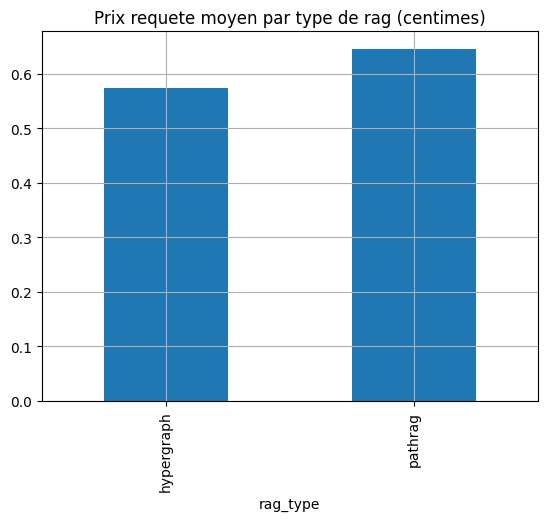

In [70]:
from matplotlib import ticker

df_tokens_usage_graph_price_grouped=df_tokens_usage_graph.groupby(["hash_query", 'rag_type', ])[["input_price", "completion_price", "total_price"]].sum().reset_index(drop=False)


df_tokens_usage_graph_price_grouped["input_price_cts"]=df_tokens_usage_graph_price_grouped["input_price"]*100
df_tokens_usage_graph_price_grouped["completion_price_cts"]=df_tokens_usage_graph_price_grouped["completion_price"]*100
df_tokens_usage_graph_price_grouped["total_price_cts"]=df_tokens_usage_graph_price_grouped["total_price"]*100

df_tokens_usage_graph_price_grouped=df_tokens_usage_graph_price_grouped.merge(
    df_tokens_usage_graph_tokens_grouped, how='inner', on=["hash_query", "rag_type"]
)

df_tokens_usage_graph_price_grouped.groupby("rag_type")["total_price_cts"].mean().plot(kind='bar', title="Prix requete moyen par type de rag (centimes)")
plt.grid(True)
plt.show()


In [67]:
import plotly.express as px

# Création du graphique
fig = px.scatter(
    df_tokens_usage_graph_price_grouped,
    x="input_price_cts",
    y="completion_price_cts",
    color="rag_type",
    title="Log scale prix input et output par requete (centimes)",
    log_x=True,
    log_y=True,
    width=1000,
    height=500,
    hover_data={
            "input_tokens": True,           # afficher
            "completion_tokens": True,       # afficher
            "total_price_cts": ":.2f",          # afficher avec 4 décimales
    }    
)

# Mise à jour de la mise en forme
fig.update_layout(
    showlegend=True,
    hovermode='closest'
)

# Mise à jour des axes pour un formatage lisible
fig.update_xaxes(
    tickformat=".2f",
    gridcolor='lightgray'
)
fig.update_yaxes(
    tickformat=".2f",
    gridcolor='lightgray'
)

# fig.add_hline(y=1, line_dash="dot", line_color="red", annotation_text="1 centime")
# fig.add_vline(x=1, line_dash="dot", line_color="red")

fig.show()

### Analyse RAGs hybrides

In [91]:
df_tokens_usage_hybrid=pd.read_json("logs/tokens_usage_hybrid.json")
print(df_tokens_usage_hybrid.shape)

# 1. Mapping des types RAG
rag_type_mapping = {
    'graph': 'pathrag', 
    'hybrid': 'hybrid', 
    'hybrid_hyde': 'hybrid_hyde'
}

records = []
columns_to_process = ['graph', 'hybrid', 'hybrid_hyde']

for col in columns_to_process:
    # Vérifie si la colonne existe dans le dataframe
    if col not in df_tokens_usage_hybrid.columns:
        continue
        
    for idx, cell_data in df_tokens_usage_hybrid[col].items():
        
        if isinstance(cell_data, dict) and cell_data:
            
            for query_hash, details in cell_data.items():
                
                # Extraction sécurisée des sous-dictionnaires de prix
                prices_final = details.get('final_response_price', {})
                prices_reranker = details.get('reranker_price', {})
                prices_hyde = details.get('hyde_tokens_price', {})
                
                # Gestion des tokens (certains JSON ont '_tokens', d'autres non)
                # On essaie la version longue, sinon la version courte
                input_tokens = details.get('final_response_input_tokens') or details.get('final_response_input')
                output_tokens = details.get('final_response_output_tokens') or details.get('final_response_output')
                reasoning_tokens = details.get('final_reasoning_output_tokens') or details.get('final_reasoning_output')
                
                row = {
                    'hash_query': query_hash,
                    'rag_type': rag_type_mapping.get(col, col),
                    'query': details.get('query', '').strip(),
                    'date': details.get('date'),
                    
                    # Tokens Génération Finale
                    'input_tokens': input_tokens,
                    'completion_tokens': output_tokens,
                    'reasoning_tokens': reasoning_tokens,
                    
                    # Prix Génération Finale
                    'input_price_final': prices_final.get('input_price'),
                    'completion_price_final': prices_final.get('completion_price'),
                    'reasoning_price_final': prices_final.get('reasoning_price'),
                    
                    # Prix Reranker (si présent)
                    'input_price_reranker': prices_reranker.get('input_price'),
                    'completion_price_reranker': prices_reranker.get('completion_price'),
                    
                    # Prix Hyde (si présent)
                    'input_price_hyde': prices_hyde.get('input_price'),
                    'completion_price_hyde': prices_hyde.get('completion_price'),
                    
                    'model': details.get('model_generation'),
                    'reranker': details.get('model_reranker')
                }
                records.append(row)

# 4. Création du DataFrame
df_flat = pd.DataFrame(records)


# ==============================================================================
# CONVERSION DES COLONNES NUMÉRIQUES
# ==============================================================================
# Liste de toutes les colonnes numériques attendues
numeric_cols = [
    'input_tokens', 'completion_tokens', 'reasoning_tokens',
    'input_price_final', 'completion_price_final', 'reasoning_price_final',
    'input_price_reranker', 'completion_price_reranker',
    'input_price_hyde', 'completion_price_hyde'
]

# On ne convertit que les colonnes qui existent vraiment dans le dataframe
existing_numeric_cols = [c for c in numeric_cols if c in df_flat.columns]
df_flat[existing_numeric_cols] = df_flat[existing_numeric_cols].apply(pd.to_numeric, errors='coerce')


# ==============================================================================
# ÉTAPE 1 : CRÉATION DES TOTAUX (Si absents)
# ==============================================================================
# On s'assure que les colonnes de base existent avant de calculer les totaux
base_price_cols = {
    'total_price_final': ['input_price_final', 'completion_price_final', 'reasoning_price_final'],
    'total_price_hyde': ['input_price_hyde', 'completion_price_hyde'],
    'total_price_reranker': ['input_price_reranker', 'completion_price_reranker']
}

for total_col, sub_cols in base_price_cols.items():
    if total_col not in df_flat.columns:
        # On prend uniquement les sous-colonnes qui existent vraiment
        valid_sub_cols = [c for c in sub_cols if c in df_flat.columns]
        if valid_sub_cols:
            df_flat[total_col] = df_flat[valid_sub_cols].fillna(0).sum(axis=1)
        else:
            df_flat[total_col] = 0.0

# ==============================================================================
# ÉTAPE 2 : HACK - Propagation des données Reranker vers hyde (non recalculé car mis en cache), par hash_query
# ==============================================================================
reranker_cols = ['input_price_reranker', 'completion_price_reranker']

# On vérifie que les colonnes source existent
if all(col in df_flat.columns for col in reranker_cols):
    
    # 1. Récupération de la première valeur non-NaN par hash_query
    reranker_lookup = df_flat.groupby('hash_query')[reranker_cols].first()
    
    # 2. Remplissage des trous (NaN) pour les lignes hybrid_hyde
    for col in reranker_cols:
        df_flat[col] = df_flat[col].fillna(df_flat['hash_query'].map(reranker_lookup[col]))
    
    # 3. Recalcul des totaux avec les nouvelles valeurs remplies
    df_flat['total_price_reranker'] = df_flat['input_price_reranker'].fillna(0) + df_flat['completion_price_reranker'].fillna(0)
    
    # Vérification de sécurité pour total_price_final avant le calcul final
    if 'total_price_final' not in df_flat.columns:
        df_flat['total_price_final'] = 0.0
    if 'total_price_hyde' not in df_flat.columns:
        df_flat['total_price_hyde'] = 0.0
        
    df_flat.rename(columns={
        "total_price_final": "generation_answer_price"
        }, 
    inplace=True)

    df_flat['total_price'] = (
        df_flat['generation_answer_price'] + 
        df_flat['total_price_reranker'] + 
        df_flat['total_price_hyde']
    )

# ==============================================================================
# ÉTAPE 3 : NETTOYAGE DES DOUBLONS & NA
# ==============================================================================
df_tokens_usage_hybrid_flat = df_flat.drop_duplicates().reset_index(drop=True)
# Affichage de vérification
df_tokens_usage_hybrid_flat.dropna(subset=['input_tokens'], inplace=True)
df_tokens_usage_hybrid_flat["model"].value_counts()

(239, 3)


model
deepseek-ai/DeepSeek-V3.2:novita               129
openai/gpt-oss-120b:cheapest                    76
Qwen/Qwen3.5-397B-A17B:novita                   10
Qwen/Qwen3-235B-A22B-Instruct-2507:cheapest      8
moonshotai/Kimi-K2-Instruct-0905:novita          8
openai/gpt-oss-120b:novita                       8
Name: count, dtype: int64

#### Table brute

In [151]:

df_tokens_usage_hybrid_flat["hyde_generation_cts"]= round( (df_tokens_usage_hybrid_flat["completion_price_hyde"]+df_tokens_usage_hybrid_flat["input_price_hyde"])*100, 2)
df_tokens_usage_hybrid_flat["total_price_reranker_cts"]= round(df_tokens_usage_hybrid_flat['total_price_reranker']*100, 2)
df_tokens_usage_hybrid_flat["generation_answer_price_cst"]=round(df_tokens_usage_hybrid_flat["generation_answer_price"]*100, 2)
df_tokens_usage_hybrid_flat["total_price_cts"]= round(df_tokens_usage_hybrid_flat['total_price']*100, 2)
print("shape:", df_tokens_usage_hybrid_flat.shape)

display(
    df_tokens_usage_hybrid_flat[
        (df_tokens_usage_hybrid_flat["model"]=="deepseek-ai/DeepSeek-V3.2:novita") 
        # & (df_tokens_usage_hybrid_flat["reranker"].str.startswith('mistral'))
    ]
)

shape: (239, 24)


,hash_query,rag_type,query,date,input_tokens,completion_tokens,reasoning_tokens,input_price_final,completion_price_final,reasoning_price_final,...,model,reranker,generation_answer_price,total_price_hyde,total_price_reranker,total_price,total_price_cts,total_price_reranker_cts,generation_answer_price_cst,hyde_generation_cts
0,10e27b16b820d8ea5076c7ccd32dd8e9,hybrid,Peux tu me faire une synthèse de ce texte en 4...,2026-03-07T18:44:41.535304,20095.0,1874.0,NaN,0.005426,0.000750,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,Qwen/Qwen3-32B:cheapest,0.006175,0.000000,0.021699,0.027875,2.79,2.17,0.62,NaN
1,5fdbc9b1e0d52ffac452e81f439381f4,hybrid,"Pour chaque intervenant, peux-tu résumer son p...",2026-03-07T19:29:07.120220,20223.0,1681.0,NaN,0.005460,0.000672,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,Qwen/Qwen3-32B:cheapest,0.006133,0.000000,0.005700,0.011833,1.18,0.57,0.61,NaN
2,87aa24f88e680293a7264af6a67390bf,hybrid,"Dans ce qui est dit, qu’est-ce qui relève plut...",2026-03-07T19:33:00.000759,19621.0,1838.0,NaN,0.005298,0.000735,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,Qwen/Qwen3-32B:cheapest,0.006033,0.000000,0.005984,0.012017,1.20,0.60,0.60,NaN
3,ff7ae5b92259b2fe924a0bd6d55983e8,hybrid,Quels sont les arguments les plus importants a...,2026-03-07T19:36:51.190028,20730.0,1936.0,NaN,0.005597,0.000774,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,Qwen/Qwen3-32B:cheapest,0.006372,0.000000,0.005922,0.012294,1.23,0.59,0.64,NaN
21,10e27b16b820d8ea5076c7ccd32dd8e9,hybrid,Peux tu me faire une synthèse de ce texte en 4...,2026-03-09T14:44:05.575542,20095.0,1865.0,NaN,0.005426,0.000746,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,Qwen/Qwen3-32B:cheapest,0.006172,0.000000,0.021699,0.027871,2.79,2.17,0.62,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,8414baff26e8e757514f3c4df6bc6b7c,hybrid_hyde,Quels arguments Nicolas Dufourcq avance-t-il d...,2026-03-17T17:33:19.802376,5236.0,782.0,0.0,0.001414,0.000313,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.001727,0.001305,0.000086,0.003117,0.31,0.01,0.17,0.13
258,e9f193fa702cbc0407a221a6248314ed,hybrid_hyde,Pourquoi Philippe Aghion propose-t-il dans ce ...,2026-03-17T17:34:22.980190,4259.0,422.0,0.0,0.001150,0.000169,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.001319,0.001325,0.000039,0.002683,0.27,0.00,0.13,0.13
259,08043ddc2002f6159c70e2bd02ee533c,hybrid_hyde,Quelles sont les mesures environnementales con...,2026-03-17T17:35:43.496507,4267.0,276.0,0.0,0.001152,0.000110,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.001262,0.001320,0.000036,0.002619,0.26,0.00,0.13,0.13
260,d0ae891539dda015a68580f96732a84d,hybrid_hyde,Comment la taxe Zucman a-t-elle finalement per...,2026-03-17T17:36:32.683438,4267.0,206.0,0.0,0.001152,0.000082,0.0,...,deepseek-ai/DeepSeek-V3.2:novita,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.001234,0.001369,0.000850,0.003453,0.35,0.09,0.12,0.14


#### Table regroupée par requeute et type d RAG

In [180]:
df_hybrid_deepseek=df_tokens_usage_hybrid_flat[df_tokens_usage_hybrid_flat['model']=="deepseek-ai/DeepSeek-V3.2:novita"]
df_price_usage_hybrid_grouped= df_hybrid_deepseek.groupby(["hash_query", "rag_type"])[["hyde_generation_cts", "total_price_reranker_cts", "generation_answer_price_cst", 'total_price_cts']].mean().reset_index()
df_price_usage_hybrid_grouped

,hash_query,rag_type,hyde_generation_cts,total_price_reranker_cts,generation_answer_price_cst,total_price_cts
0,08043ddc2002f6159c70e2bd02ee533c,hybrid,NaN,0.080000,0.130000,0.210
1,08043ddc2002f6159c70e2bd02ee533c,hybrid_hyde,0.1300,0.040000,0.135000,0.305
2,0926bdf320f2715e10a64e045db4f5d9,hybrid,NaN,0.040000,0.190000,0.220
3,0926bdf320f2715e10a64e045db4f5d9,hybrid_hyde,0.1300,0.210000,0.180000,0.525
4,0a7e6e624e63a72e08248483a956f58c,hybrid,NaN,0.000000,0.170000,0.170
...,...,...,...,...,...,...
59,f8f2eb12e21009d697554a2b5a7dea9a,hybrid_hyde,0.1300,0.143333,0.123333,0.400
60,fe701eb2cbda2b2f53b3d8bda91ccb65,hybrid,NaN,0.010000,0.200000,0.200
61,fe701eb2cbda2b2f53b3d8bda91ccb65,hybrid_hyde,0.1300,0.230000,0.195000,0.550
62,ff7ae5b92259b2fe924a0bd6d55983e8,hybrid,NaN,1.120000,0.645000,1.760


#### Moyennes et distribution des tokens

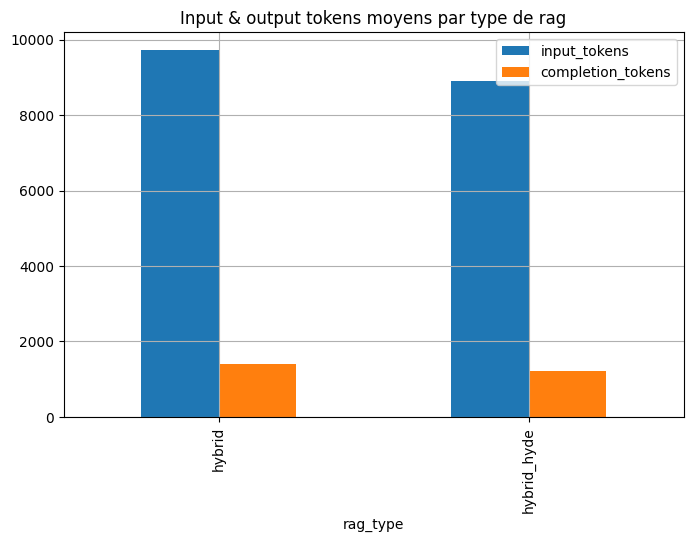

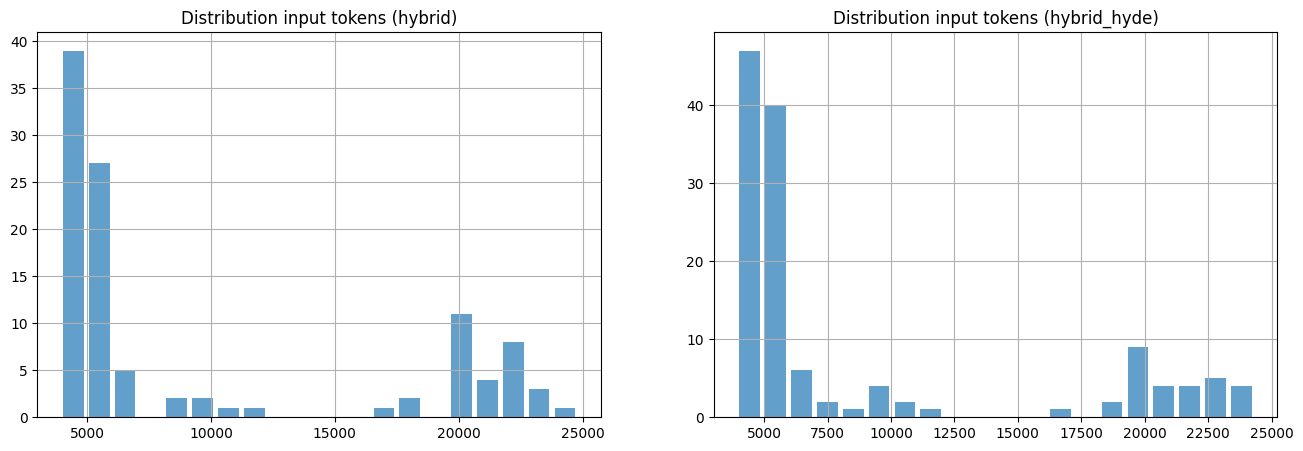

In [143]:
df_tokens_usage_hybrid_flat.groupby("rag_type")[["input_tokens", "completion_tokens"]].mean().plot(kind='bar', title="Input & output tokens moyens par type de rag", figsize=(8, 5), grid=True, )
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rag_types = df_tokens_usage_hybrid_flat['rag_type'].unique()
for i, rag in enumerate(rag_types):
    df_subset = df_tokens_usage_hybrid_flat[df_tokens_usage_hybrid_flat['rag_type'] == rag]
    axes[i].hist(df_subset['input_tokens'], bins=20, alpha=0.7, rwidth=0.8)
    axes[i].set_title(f"Distribution input tokens ({rag})")
    axes[i].grid(True)
plt.show()


#### Moyennes et distribution des prix

0.9

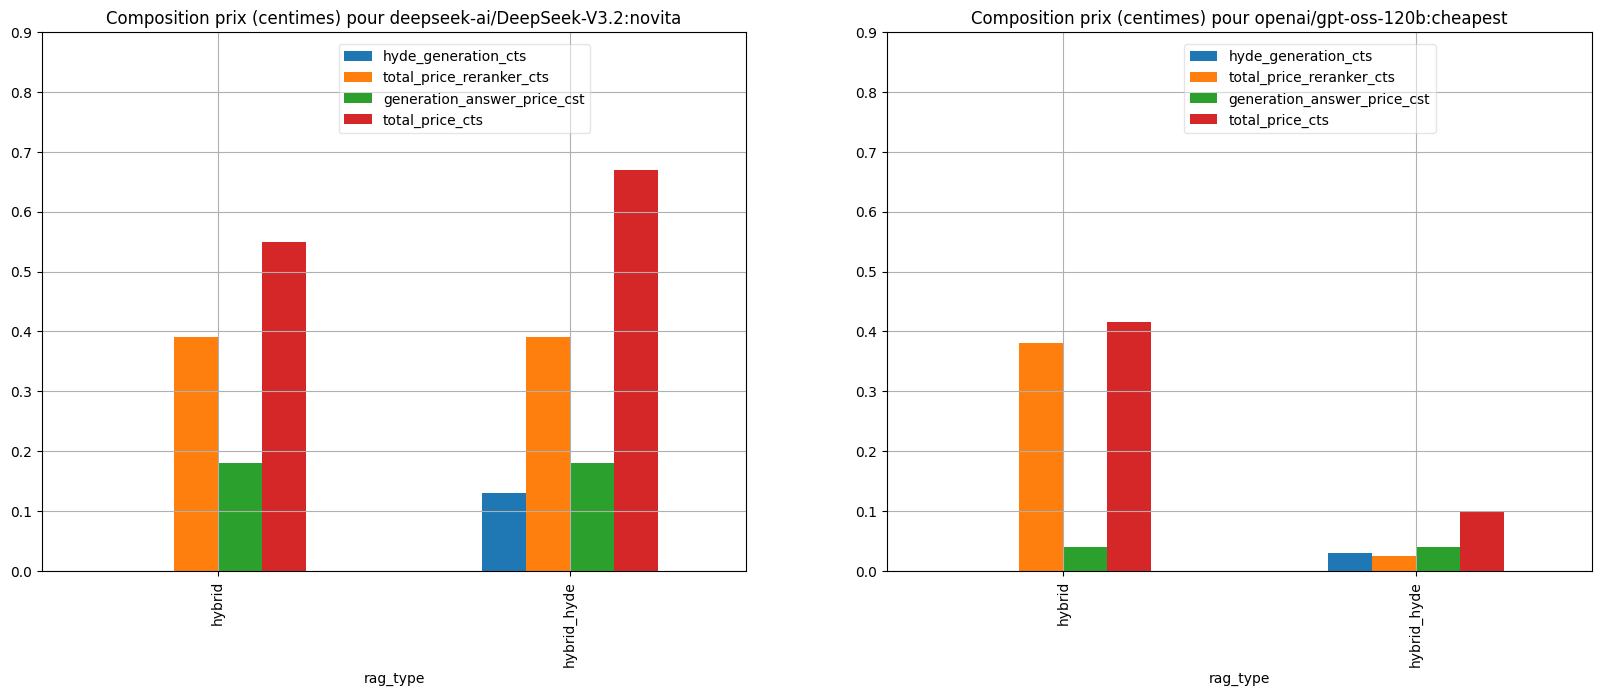

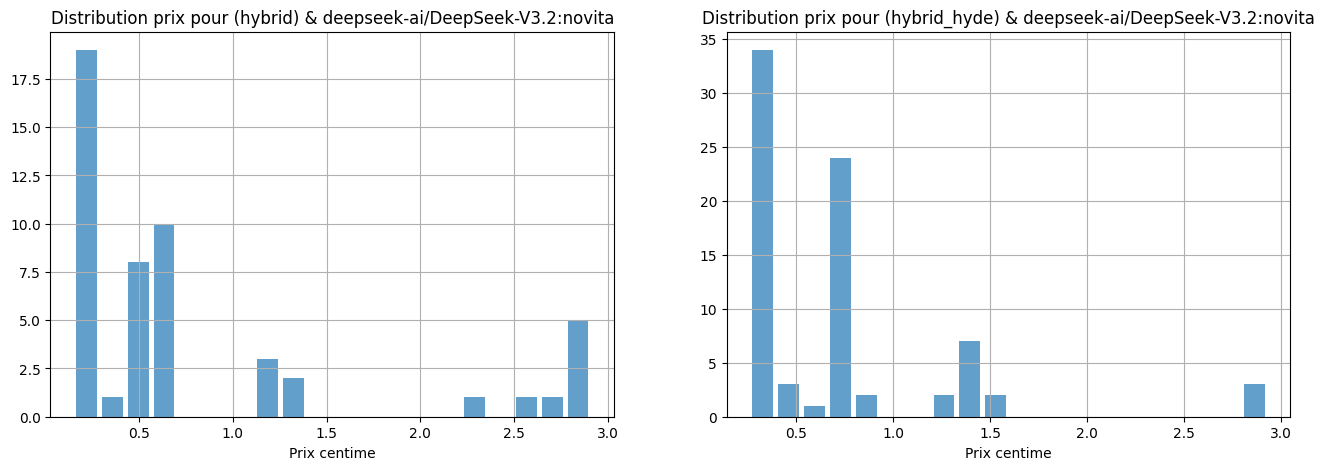

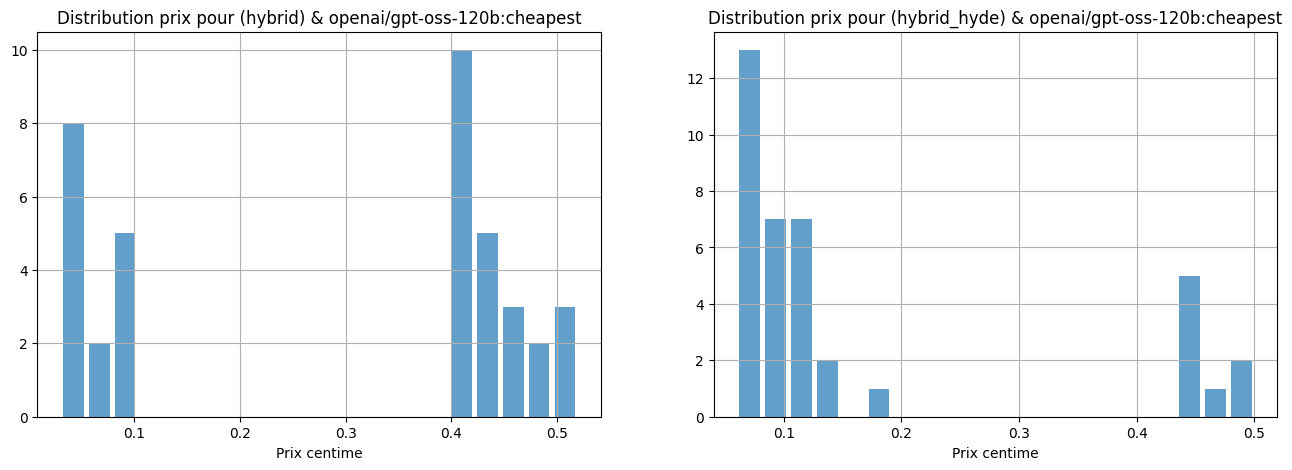

In [220]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
top2_models = df_tokens_usage_hybrid_flat['model'].value_counts().head(2).index.to_list()

y_lim=0.9
display(y_lim)
for i, llm in enumerate(top2_models):
    df_subset= df_tokens_usage_hybrid_flat[df_tokens_usage_hybrid_flat["model"]==llm]
    df_subset.groupby("rag_type")[["hyde_generation_cts", "total_price_reranker_cts", 'generation_answer_price_cst', "total_price_cts"]].median().plot(kind='bar', ax=axes[i])
    axes[i].legend(loc='lower center', bbox_to_anchor=(0.6, 0.8), framealpha=0.5)
    axes[i].set_title(f"Composition prix (centimes) pour {llm}")
    axes[i].grid(True)
    axes[i].set_ylim(0, y_lim)
    # .groupby("rag_type")[["hyde_generation_cts", "total_price_reranker_cts", 'generation_answer_price_cst', "total_price_cts"]].mean().plot(kind='bar', title="Composition moyenne du prix par type de rag (LLM deepseek 3.2)", figsize=(12, 7), grid=True, )
plt.show()


for llm in top2_models:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    rag_types = df_tokens_usage_hybrid_flat['rag_type'].unique()

    for i, rag in enumerate(rag_types):
        df_subset = df_tokens_usage_hybrid_flat[(df_tokens_usage_hybrid_flat['rag_type'] == rag) & (df_tokens_usage_hybrid_flat["model"]==llm)]
        axes[i].hist(df_subset['total_price_cts'], bins=20, alpha=0.7, rwidth=0.8)
        axes[i].set_title(f"Distribution prix pour ({rag}) & {llm}")
        axes[i].set_xlabel("Prix centime")
        axes[i].grid(True)    

    plt.show()


#### Prix des requetes selon input / output tokens

In [231]:
import plotly.express as px

# Création du graphique
model=top2_models[0]
title=f"""Log scale prix des requetes selon reranker et generation | {model.split('/')[1]}  (prix en centimes)"""
fig = px.scatter(
    df_tokens_usage_hybrid_flat[df_tokens_usage_hybrid_flat["model"]==model],        
    x="total_price_reranker_cts",
    y='generation_answer_price_cst',
    color="rag_type",
    title=title,
    log_x=True,
    log_y=True,
    width=1200,
    height=600,
    hover_data={
            "input_tokens": True,           # afficher
            "completion_tokens": True,       # afficher            
            "hyde_generation_cts": ":.2f",          # afficher avec 2 décimales
            "total_price_cts": ":.2f",          # afficher avec 2 décimales
    }    
)

# Mise à jour de la mise en forme
fig.update_layout(
    showlegend=True,
    hovermode='closest'
)

# Mise à jour des axes pour un formatage lisible
fig.update_xaxes(
    tickformat=".2f",
    gridcolor='lightgray'
)
fig.update_yaxes(
    tickformat=".2f",
    gridcolor='lightgray'
)

# fig.add_hline(y=1, line_dash="dot", line_color="red", annotation_text="1 centime")
# fig.add_vline(x=1, line_dash="dot", line_color="red")

fig.show()

In [120]:
import json

# 1. Simulation de vos données (ou chargement via json.load())
with open('logs/tokens_usage_hybrid.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

data_content = raw_data[0]["hybrid"]

records = []
for item in raw_data:
    # Vérifier que la clé "hybrid" existe et n'est pas vide
    if "hybrid" in item and item["hybrid"]:
        for hash_key, content in item["hybrid"].items():
            row = content.copy()
            row['hash'] = hash_key
            records.append(row)

# 3. Normalisation et aplatissement de tous les champs imbriqués
df = pd.json_normalize(records)

# 4. Réorganisation des colonnes (Hash en premier)
if 'hash' in df.columns:
    cols = ['hash'] + [c for c in df.columns if c != 'hash']
    df = df[cols]

# Remplacer les points par des underscores pour faciliter l'accès
df.columns = [c.replace('.', '_') for c in df.columns]
df["reranker_price_input_price_cts"]=round(df["reranker_price_input_price"]*100, 2)
df["reranker_price_completion_cts"]=round(df["reranker_price_completion_price"]*100, 2)
df["reranker_price_total_cts"]=df["reranker_price_input_price_cts"]+df["reranker_price_completion_cts"]
df_reranker=df[[
    "date", "query",
    'model_reranker',
        'reranker_input_tokens',
       'reranker_output_tokens', 'reranker_llm', 'reranker_price_input_price_cts',
       'reranker_price_completion_cts', "reranker_price_total_cts"]].dropna()

df_reranker


,date,query,model_reranker,reranker_input_tokens,reranker_output_tokens,reranker_llm,reranker_price_input_price_cts,reranker_price_completion_cts,reranker_price_total_cts
1,2026-03-07T19:29:07.120220,"Pour chaque intervenant, peux-tu résumer son ...",Qwen/Qwen3-32B:cheapest,69169.0,666.0,Qwen/Qwen3-32B:cheapest,0.55,0.02,0.57
2,2026-03-07T19:33:00.000759,"\n Dans ce qui est dit, qu’...",Qwen/Qwen3-32B:cheapest,72721.0,666.0,Qwen/Qwen3-32B:cheapest,0.58,0.02,0.60
3,2026-03-07T19:33:00.000759,"\n Dans ce qui est dit, qu’...",Qwen/Qwen3-32B:cheapest,72721.0,666.0,Qwen/Qwen3-32B:cheapest,0.58,0.02,0.60
4,2026-03-07T19:36:51.190028,\n Quels sont les arguments...,Qwen/Qwen3-32B:cheapest,71944.0,666.0,Qwen/Qwen3-32B:cheapest,0.58,0.02,0.60
5,2026-03-07T19:33:00.000759,"\n Dans ce qui est dit, qu’...",Qwen/Qwen3-32B:cheapest,72721.0,666.0,Qwen/Qwen3-32B:cheapest,0.58,0.02,0.60
...,...,...,...,...,...,...,...,...,...
499,2026-03-16T13:44:14.300528,"Philippe Aghion se revendique d'une ""approche ...",openai/gpt-oss-120b:cheapest,57458.0,9499.0,openai/gpt-oss-120b:cheapest,0.23,0.14,0.37
500,2026-03-16T13:45:20.789952,"Philippe Aghion critique sévèrement la ""taxe Z...",openai/gpt-oss-120b:cheapest,59735.0,11021.0,openai/gpt-oss-120b:cheapest,0.24,0.17,0.41
502,2026-03-16T13:43:34.420601,Le podcast situe le point de départ de la déri...,openai/gpt-oss-120b:cheapest,57363.0,12570.0,openai/gpt-oss-120b:cheapest,0.23,0.19,0.42
503,2026-03-16T13:44:14.300528,"Philippe Aghion se revendique d'une ""approche ...",openai/gpt-oss-120b:cheapest,57458.0,9499.0,openai/gpt-oss-120b:cheapest,0.23,0.14,0.37
